# Hit Song Prediction — Spotify Tracks Dataset
**Machine Learning Project — M1 IDD**

**Dataset :** [Spotify Tracks Dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset) — 114 000 chansons, source : Spotify Web API via Kaggle (maharshipandya).

**Tâche :** Prédire si une chanson est un *hit* (classification binaire) à partir de ses caractéristiques audio.

**Plan :**
1. Chargement & inspection des données
2. Analyse exploratoire (EDA)
3. Préparation des données (encodage, split train/test)
4. Sélection des variables
5. Méthodes ML avec cross-validation
6. Comparaison des méthodes & analyse des résultats
7. Évaluation finale sur le test set


## 0. Imports

In [15]:
import copy
import numpy as np
import scipy
import pandas
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (f1_score, confusion_matrix, precision_recall_fscore_support,
                              roc_curve, auc, classification_report)
from sklearn.impute import SimpleImputer

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("scikit-learn version:", sklearn.__version__)
print("pandas version:", pandas.__version__)


scikit-learn version: 1.6.1
pandas version: 2.2.3


## 1. Chargement & inspection des données

Le dataset est disponible sur Kaggle :
https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset

**Variables disponibles (20 colonnes) :**
| Variable | Type | Description |
|---|---|---|
| `track_id` | str | Identifiant unique Spotify |
| `artists` | str | Nom(s) de l'artiste |
| `album_name` | str | Nom de l'album |
| `track_name` | str | Nom de la chanson |
| `popularity` | int [0–100] | **Variable cible** : score de popularité Spotify |
| `duration_ms` | int | Durée en millisecondes |
| `explicit` | bool | Contenu explicite |
| `danceability` | float [0–1] | Capacité à danser |
| `energy` | float [0–1] | Intensité perceptuelle |
| `key` | int [0–11] | Tonalité musicale |
| `loudness` | float | Intensité sonore (dB) |
| `mode` | int {0,1} | Majeur (1) ou mineur (0) |
| `speechiness` | float [0–1] | Présence de paroles |
| `acousticness` | float [0–1] | Caractère acoustique |
| `instrumentalness` | float [0–1] | Absence de voix |
| `liveness` | float [0–1] | Enregistrement en live |
| `valence` | float [0–1] | Positivité musicale |
| `tempo` | float | Tempo (BPM) |
| `time_signature` | int | Signature rythmique |
| `track_genre` | str | Genre musical |


In [16]:
df = pandas.read_csv("dataset.csv")
print("Shape:", df.shape)
df.head()


Shape: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [17]:
print("Colonnes :")
print(df.columns.tolist())
print()
print("Types :")
print(df.dtypes)

Colonnes :
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Types :
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object


## 2. Analyse exploratoire des données (EDA)


### 2.1 Vérifications communes

In [18]:
# Valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())
print()
print("Proportion de NaN :")
print((df.isnull().sum() / len(df)).round(4))

Valeurs manquantes par colonne :
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Proportion de NaN :
Unnamed: 0          0.0
track_id            0.0
artists             0.0
album_name          0.0
track_name          0.0
popularity          0.0
duration_ms         0.0
explicit            0.0
danceability        0.0
energy              0.0
key                 0.0
loudness            0.0
mode                0.0
speechiness         0.0
acousticness        0.0
instrumentalness    0.0
liveness            0.0
valence             0.0
tempo               0.0
time_signature 

In [19]:
# Doublons (même track_id)
print("Nombre de doublons (track_id) :", df.duplicated(subset=["track_id"]).sum())
# On garde la ligne avec la popularité maximale pour chaque chanson
df = df.sort_values("popularity", ascending=False).drop_duplicates(subset=["track_id"]).reset_index(drop=True)
print("Shape après dédoublonnage :", df.shape)

Nombre de doublons (track_id) : 24259
Shape après dédoublonnage : (89741, 21)


In [20]:
print("Description statistique des variables numériques :")
df.describe()


Description statistique des variables numériques :


,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,89741.000000,89741.000000,8.974100e+04,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000
mean,56880.578286,33.207196,2.291418e+05,0.562166,0.634458,5.283549,-8.499004,0.636966,0.087442,0.328289,0.173413,0.216970,0.469477,122.058316,3.897427
std,33338.746443,20.574270,1.129477e+05,0.176691,0.256605,3.559897,5.221490,0.480877,0.113277,0.338321,0.323848,0.194884,0.262864,30.117532,0.453435
min,1.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,26962.000000,19.000000,1.730400e+05,0.450000,0.457000,2.000000,-10.322000,0.000000,0.036000,0.017100,0.000000,0.098200,0.249000,99.264000,4.000000
50%,55997.000000,33.000000,2.132930e+05,0.576000,0.676000,5.000000,-7.185000,1.000000,0.048900,0.188000,0.000058,0.132000,0.457000,122.013000,4.000000
75%,84992.000000,49.000000,2.642930e+05,0.692000,0.853000,8.000000,-5.108000,1.000000,0.085900,0.625000,0.097600,0.279000,0.682000,140.077000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


### 2.2 Variable cible : `popularity`

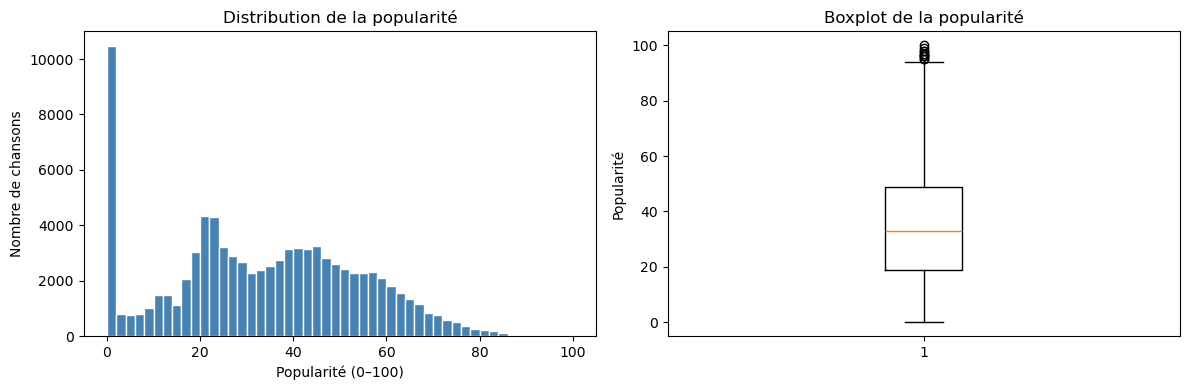

Moyenne : 33.21
Variance : 423.30
Médiane : 33.00


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution
axes[0].hist(df["popularity"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution de la popularité")
axes[0].set_xlabel("Popularité (0–100)")
axes[0].set_ylabel("Nombre de chansons")

# Boxplot
axes[1].boxplot(df["popularity"], vert=True)
axes[1].set_title("Boxplot de la popularité")
axes[1].set_ylabel("Popularité")

plt.tight_layout()
plt.show()

print(f"Moyenne : {df['popularity'].mean():.2f}")
print(f"Variance : {df['popularity'].var():.2f}")
print(f"Médiane : {df['popularity'].median():.2f}")

### 2.3 Création de la variable cible binaire `is_hit`

On définit un *hit* comme une chanson dont le score de popularité est **supérieur ou égal au 75e percentile**.
Ce seuil est justifié car :
- il est objectif et reproductible ;
- il capture les chansons réellement populaires (top 25%) ;
- il crée un dataset légèrement déséquilibré, réaliste d'un vrai problème de classification.


Seuil de popularité (75e percentile) : 49.0

Répartition des classes :
  Non-hit (0) : 67220 (74.9%)
  Hit     (1) : 22521 (25.1%)


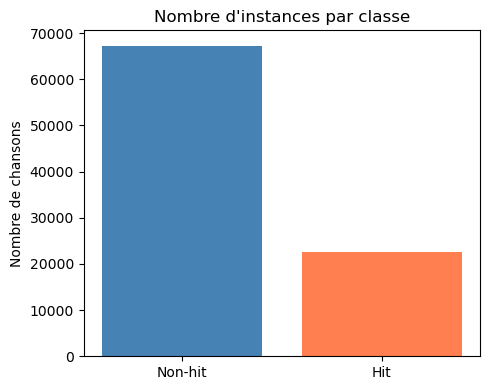

In [22]:

threshold = df["popularity"].quantile(0.75)
print(f"Seuil de popularité (75e percentile) : {threshold:.1f}")

df["is_hit"] = (df["popularity"] >= threshold).astype(int)

# Répartition des classes
counts = df["is_hit"].value_counts()
print()
print("Répartition des classes :")
print(f"  Non-hit (0) : {counts[0]} ({counts[0]/len(df)*100:.1f}%)")
print(f"  Hit     (1) : {counts[1]} ({counts[1]/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Non-hit", "Hit"], [counts[0], counts[1]], color=["steelblue", "coral"])
ax.set_title("Nombre d'instances par classe")
ax.set_ylabel("Nombre de chansons")
plt.tight_layout()
plt.show()

#### DIAGNOSTIC DU DÉSÉQUILIBRE 
Le dataset est déséquilibré : ~75% Non-hit, ~25% Hit. Un classifieur naïf qui prédit toujours "Non-hit" obtiendrait déjà ~75% d'accuracy.

L'accuracy seule est donc une métrique trompeuse ici.

→ On utilisera le F1-score (macro) comme métrique principale dans le GridSearchCV.

→ On activera class_weight='balanced' sur les modèles qui le supportent, ce qui pondère les erreurs inversement proportionnellement à la fréquence de chaque classe.

### 2.4 Analyse univariée des variables numériques

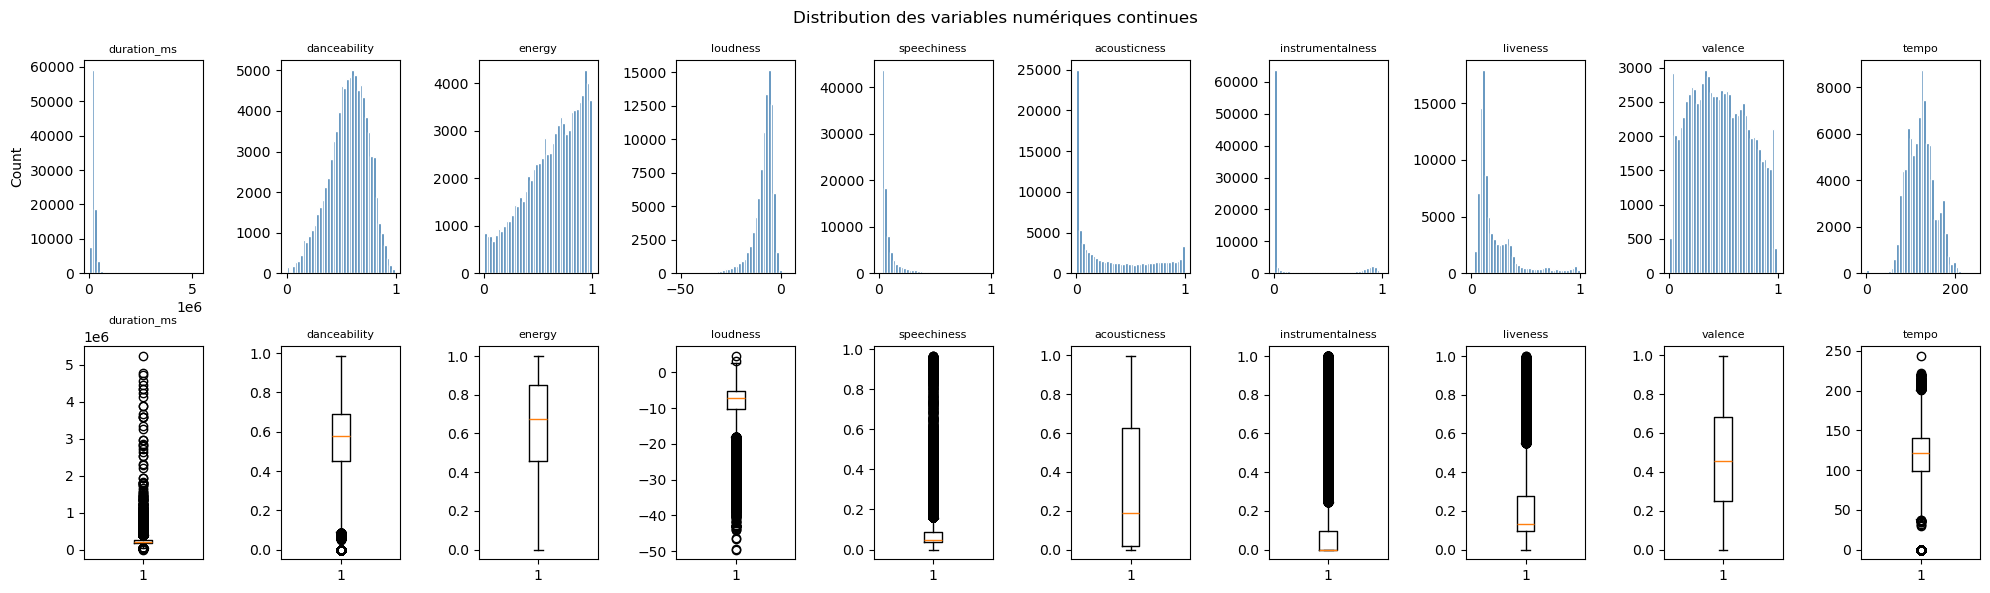

In [23]:
# Variables numériques continues d'intérêt
features_num = ["duration_ms", "danceability", "energy", "loudness", "speechiness",
                "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

fig, axes = plt.subplots(2, len(features_num), figsize=(20, 6))

for i, feat in enumerate(features_num):
    # Histogramme
    axes[0, i].hist(df[feat], bins=40, color="steelblue", edgecolor="white")
    axes[0, i].set_title(feat, fontsize=8)
    axes[0, i].set_ylabel("Count" if i == 0 else "")
    
    # Boxplot
    axes[1, i].boxplot(df[feat])
    axes[1, i].set_title(feat, fontsize=8)

plt.suptitle("Distribution des variables numériques continues", fontsize=12)
plt.tight_layout()
plt.show()

In [24]:
# Statistiques descriptives par variable
print("Statistiques descriptives :")
print(f"{'Variable':<20} {'Moyenne':>10} {'Variance':>10}")
print("-" * 42)
for feat in features_num:
    print(f"{feat:<20} {df[feat].mean():>10.4f} {df[feat].var():>10.4f}")

Statistiques descriptives :
Variable                Moyenne   Variance
------------------------------------------
duration_ms          229141.8122 12757192239.9438
danceability             0.5622     0.0312
energy                   0.6345     0.0658
loudness                -8.4990    27.2640
speechiness              0.0874     0.0128
acousticness             0.3283     0.1145
instrumentalness         0.1734     0.1049
liveness                 0.2170     0.0380
valence                  0.4695     0.0691
tempo                  122.0583   907.0657


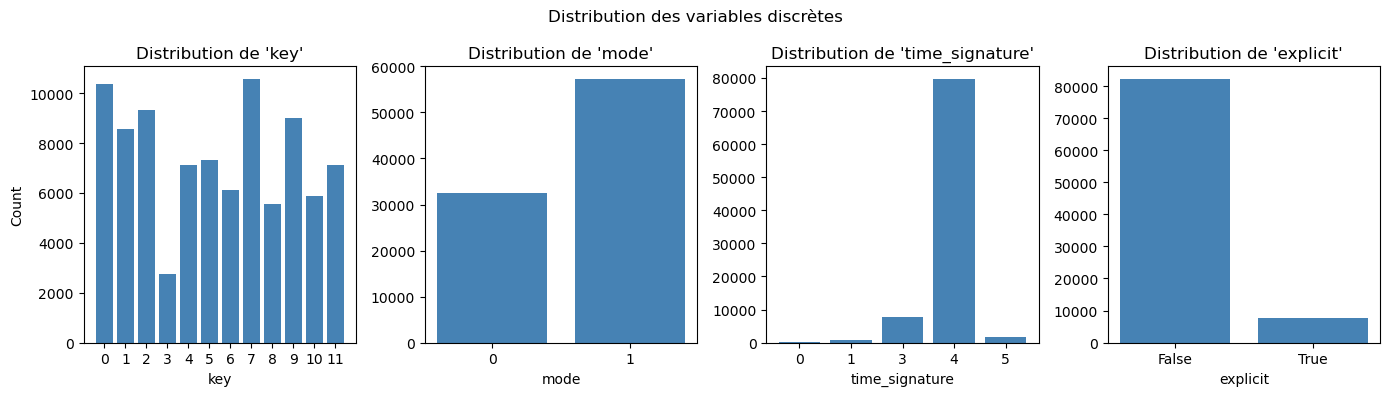

In [25]:
# Variables discrètes
features_discrete = ["key", "mode", "time_signature", "explicit"]

fig, axes = plt.subplots(1, len(features_discrete), figsize=(14, 4))

for i, feat in enumerate(features_discrete):
    counts_feat = df[feat].value_counts().sort_index()
    axes[i].bar(counts_feat.index.astype(str), counts_feat.values, color="steelblue")
    axes[i].set_title(f"Distribution de '{feat}'")
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Count" if i == 0 else "")

plt.suptitle("Distribution des variables discrètes", fontsize=12)
plt.tight_layout()
plt.show()

/var/folders/l3/xbmtc6l11rg0847wv607y9jw0000gn/T/ipykernel_54443/1883636673.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(genre_counts.index, rotation=45, ha="right", fontsize=9)


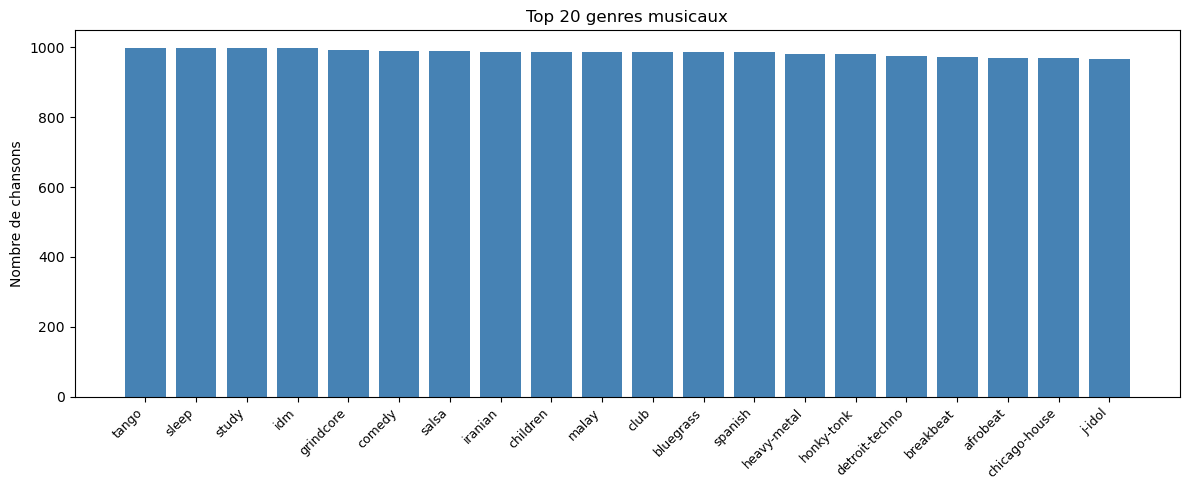

Nombre total de genres : 114


In [26]:
# Variable catégorielle : genre
n_genres_shown = 20
genre_counts = df["track_genre"].value_counts().head(n_genres_shown)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(genre_counts.index, genre_counts.values, color="steelblue")
ax.set_title(f"Top {n_genres_shown} genres musicaux")
ax.set_xticklabels(genre_counts.index, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Nombre de chansons")
plt.tight_layout()
plt.show()

print(f"Nombre total de genres : {df['track_genre'].nunique()}")

### 2.5 Analyse de corrélation avec la cible

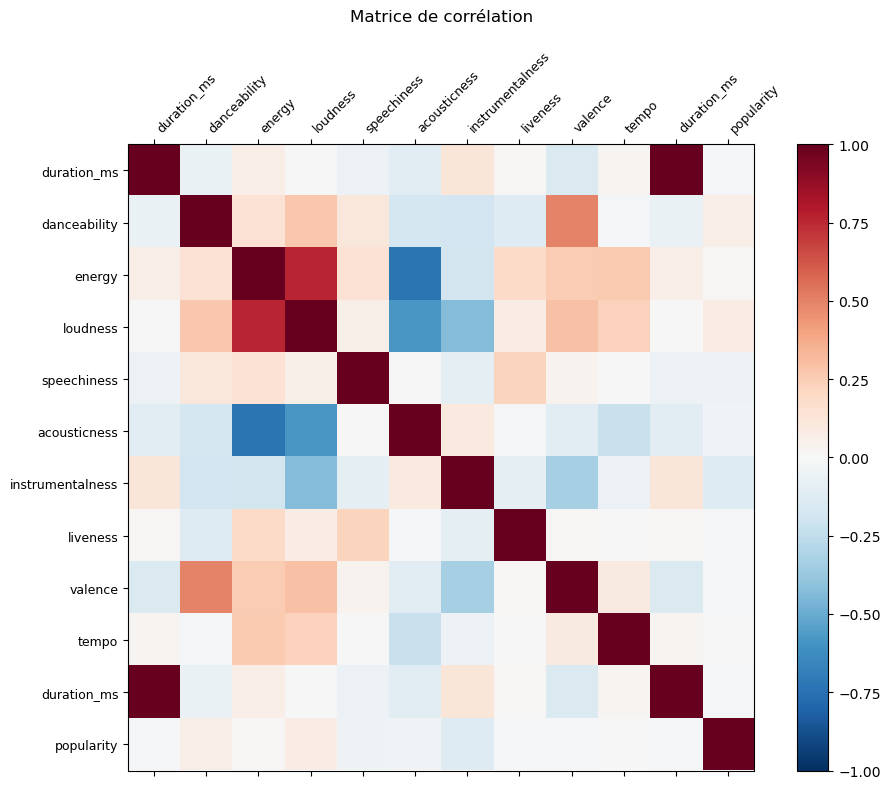


Corrélations avec 'popularity' :
popularity          1.000000
loudness            0.071687
danceability        0.064315
energy              0.013613
tempo               0.007317
valence            -0.011564
liveness           -0.013955
duration_ms        -0.023118
duration_ms        -0.023118
acousticness       -0.038839
speechiness        -0.047197
instrumentalness   -0.127635
Name: popularity, dtype: float64


In [27]:
# Corrélations avec la popularité
numeric_cols = features_num + ["duration_ms", "popularity"]
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.matshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="left", fontsize=9)
ax.set_yticklabels(corr_matrix.columns, fontsize=9)
plt.title("Matrice de corrélation", pad=20)
plt.tight_layout()
plt.show()

print("\nCorrélations avec 'popularity' :")
print(corr_matrix["popularity"].sort_values(ascending=False))

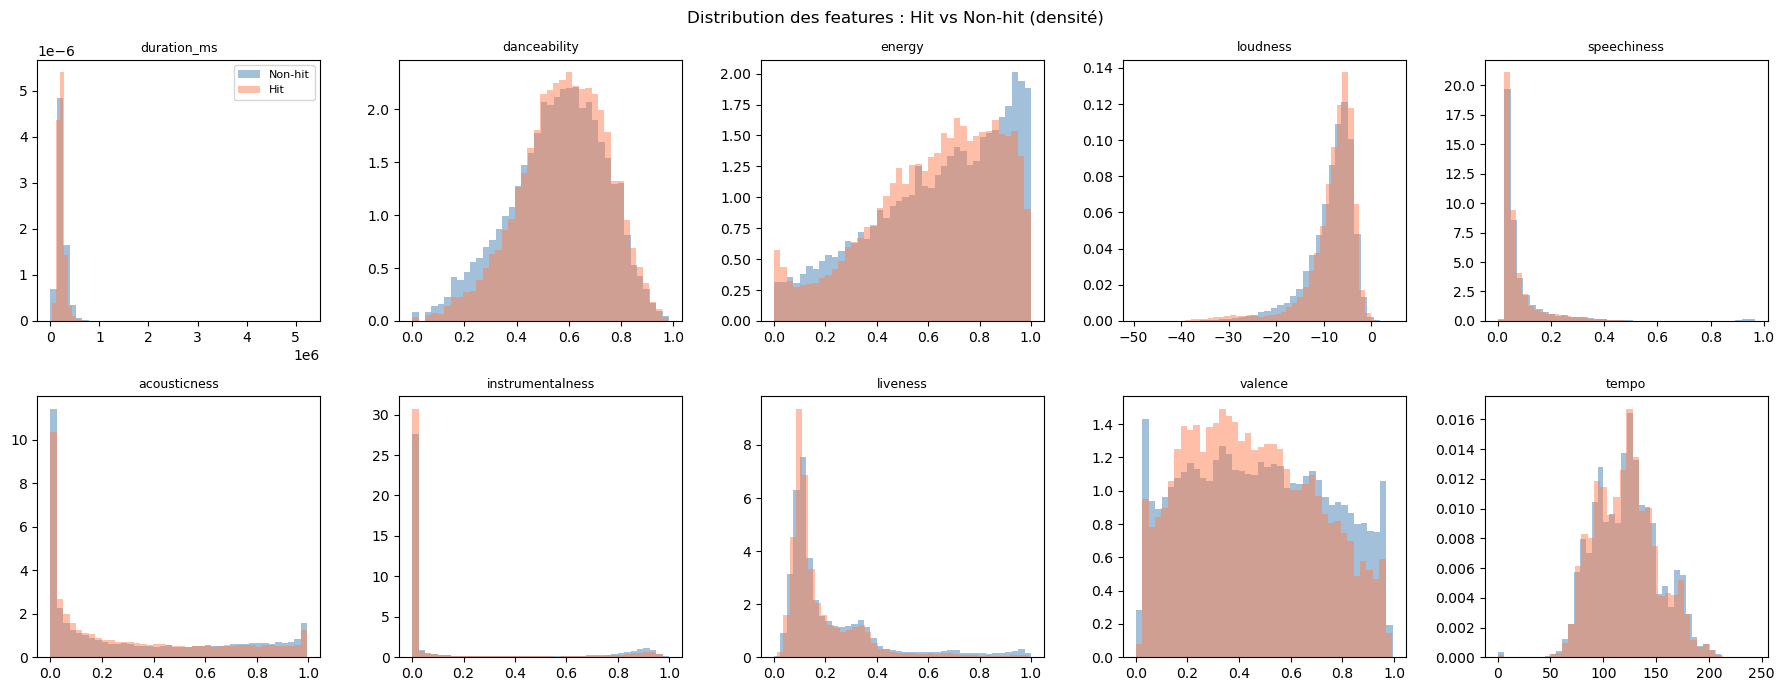

In [28]:
# Distributions des features par classe (hit vs non-hit)
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, feat in enumerate(features_num):
    hit_data = df[df["is_hit"] == 1][feat]
    non_hit_data = df[df["is_hit"] == 0][feat]
    
    axes[i].hist(non_hit_data, bins=40, alpha=0.5, label="Non-hit", color="steelblue", density=True)
    axes[i].hist(hit_data, bins=40, alpha=0.5, label="Hit", color="coral", density=True)
    axes[i].set_title(feat, fontsize=9)
    if i == 0:
        axes[i].legend(fontsize=8)

for j in range(len(features_num), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution des features : Hit vs Non-hit (densité)", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Préparation des données

### 3.1 Encodage & sélection des features

In [29]:
from sklearn.preprocessing import OneHotEncoder
import scipy.sparse as sp

# Encodage des variables catégorielles
# explicit : booléen → int
df["explicit"] = df["explicit"].astype(int)

# Transformations log1p 
# Ces trois variables ont des distributions très skewed (quasi-exponentielles) : log1p(x) = log(1+x) gère le cas x=0 sans erreur
df["instrumentalness_log"] = np.log1p(df["instrumentalness"])
df["acousticness_log"]     = np.log1p(df["acousticness"])
df["liveness_log"]         = np.log1p(df["liveness"])

# On enlève 'track_genre' de la liste car on va le traiter à part
features_base = [
    "danceability", "energy", "loudness", "speechiness",
    "instrumentalness_log",   # ← log, pas la version brute
    "acousticness_log",       # ← log
    "liveness_log",           # ← log
    "valence", "tempo", "duration_ms",
    "explicit", "key", "mode", "time_signature"
]
X_num = df[features_base].values

# Encodage One-Hot pour le genre (crée 114 colonnes de 0 et 1)
ohe = OneHotEncoder(sparse_output=True, handle_unknown="ignore")
X_genre_sparse = ohe.fit_transform(df[["track_genre"]])

# On utilise hstack (horizontal stack) pour coller les colonnes côte à côte
X = sp.hstack([X_num, X_genre_sparse])

target = "is_hit"
y = df[target]

print(f"Nombre de features de base : {len(features_base)}")
print(f"Nombre de genres encodés   : {X_genre_sparse.shape[1]}")
print(f"Taille finale de X         : {X.shape} (lignes, colonnes)")
print(f"Répartition cible  : {y.value_counts().to_dict()}")

Nombre de features de base : 14
Nombre de genres encodés   : 114
Taille finale de X         : (89741, 128) (lignes, colonnes)
Répartition cible  : {0: 67220, 1: 22521}


### 3.2 Imputation des valeurs manquantes

In [30]:
# On vérifie les NaN dans les features sélectionnées
nan_counts = df[features_base + ["track_genre"]].isnull().sum()
if nan_counts.sum() == 0:
    print("Aucune valeur manquante dans les features sélectionnées.")
else: 
    print("Valeurs manquantes :")
    print(nan_counts[nan_counts > 0])

Aucune valeur manquante dans les features sélectionnées.


### 3.3 Séparation train / test

⚠️ Le test set est isolé dès maintenant et ne sera utilisé qu'à l'étape finale.


Le test set est isolé dès maintenant et ne sera utilisé qu'à l'étape finale.


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# Extraction du nombre de lignes pour le calcul du %
total_rows = X.shape[0] 
train_rows = X_train.shape[0] 
test_rows = X_test.shape[0] 

print(f"Train : {X_train.shape} exemples ({train_rows / total_rows*100:.1f}%)")
print(f"Test  : {X_test.shape} exemples ({test_rows / total_rows*100:.1f}%)")
print()
print("Répartition dans le train :")
print(y_train.value_counts(normalize=True).round(3))
print("Répartition dans le test :")
print(y_test.value_counts(normalize=True).round(3))


Train : (71792, 128) exemples (80.0%)
Test  : (17949, 128) exemples (20.0%)

Répartition dans le train :
is_hit
0    0.749
1    0.251
Name: proportion, dtype: float64
Répartition dans le test :
is_hit
0    0.749
1    0.251
Name: proportion, dtype: float64


In [32]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── 1. Préparation des données ────────────────────────────────────────────────
# On travaille sur un sous-échantillon pour la lisibilité et la rapidité
# (afficher 90 000 points rendrait le graphe illisible)
np.random.seed(RANDOM_STATE)
N_DISPLAY = 3000

idx_hit     = np.where(y_train.values == 1)[0]
idx_nonhit  = np.where(y_train.values == 0)[0]

# On tire autant de Non-hits que de Hits pour un affichage équilibré
n_each = min(N_DISPLAY // 2, len(idx_hit))
idx_sample_hit    = np.random.choice(idx_hit,    n_each, replace=False)
idx_sample_nonhit = np.random.choice(idx_nonhit, n_each, replace=False)
idx_sample = np.concatenate([idx_sample_hit, idx_sample_nonhit])

# Extraction de la sous-matrice (dense pour PCA)
if hasattr(X_train, 'toarray'):
    X_sample = X_train[idx_sample].toarray()
else:
    X_sample = X_train.iloc[idx_sample].values

y_sample = y_train.values[idx_sample]

print(f"Sous-échantillon : {n_each} Hits + {n_each} Non-hits = {len(idx_sample)} points")

# ── 2. Normalisation + PCA ────────────────────────────────────────────────────
# StandardScaler avec with_mean=False car la matrice contient des colonnes OHE
scaler_pca = StandardScaler(with_mean=False)
X_scaled   = scaler_pca.fit_transform(X_sample)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_scaled)

var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100
var_total = var_pc1 + var_pc2

print(f"Variance expliquée — PC1 : {var_pc1:.1f}%  |  PC2 : {var_pc2:.1f}%  |  Total : {var_total:.1f}%")


Sous-échantillon : 1500 Hits + 1500 Non-hits = 3000 points
Variance expliquée — PC1 : 2.8%  |  PC2 : 1.7%  |  Total : 4.5%


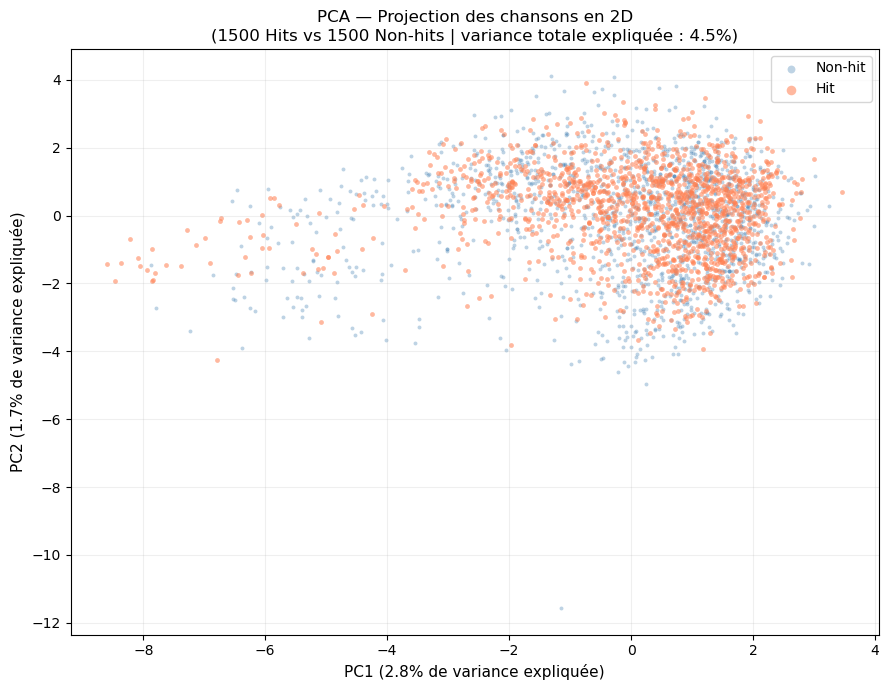


Interprétation :
  Les deux classes se chevauchent fortement dans ce plan 2D.
  C'est cohérent avec les corrélations quasi-nulles observées en EDA.
  Seulement 4.5% de la variance est capturée en 2D sur 128 features.


In [33]:
# ── 3. Visualisation principale ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

colors  = {0: "steelblue", 1: "coral"}
labels  = {0: "Non-hit",   1: "Hit"}
alphas  = {0: 0.35,        1: 0.55}
sizes   = {0: 8,           1: 12}

for cls in [0, 1]:
    mask = y_sample == cls
    ax.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=colors[cls], label=labels[cls],
        alpha=alphas[cls], s=sizes[cls], linewidths=0
    )

ax.set_xlabel(f"PC1 ({var_pc1:.1f}% de variance expliquée)", fontsize=11)
ax.set_ylabel(f"PC2 ({var_pc2:.1f}% de variance expliquée)", fontsize=11)
ax.set_title(
    f"PCA — Projection des chansons en 2D\n"
    f"({n_each} Hits vs {n_each} Non-hits | variance totale expliquée : {var_total:.1f}%)",
    fontsize=12
)
ax.legend(fontsize=10, markerscale=2)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print()
print("Interprétation :")
print(f"  Les deux classes se chevauchent fortement dans ce plan 2D.")
print(f"  C'est cohérent avec les corrélations quasi-nulles observées en EDA.")
print(f"  Seulement {var_total:.1f}% de la variance est capturée en 2D sur 128 features.")


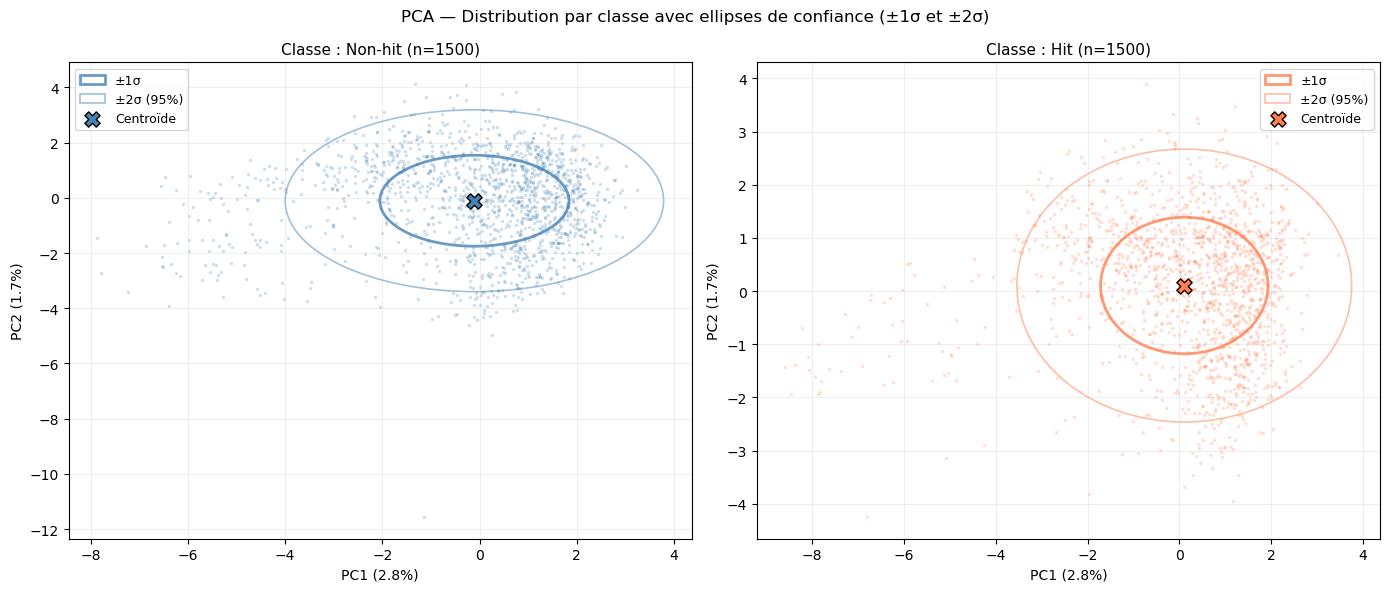

In [34]:
# ── 4. Visualisation avancée : densité par classe ─────────────────────────────
# Montre plus clairement où se concentrent les deux classes

try:
    from scipy.stats import gaussian_kde

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, cls, color, label in zip(
        axes, [0, 1], ["steelblue", "coral"], ["Non-hit", "Hit"]
    ):
        mask = y_sample == cls
        x_cls = X_2d[mask, 0]
        y_cls = X_2d[mask, 1]

        # Scatter
        ax.scatter(x_cls, y_cls, c=color, alpha=0.25, s=6, linewidths=0)

        # Ellipse de confiance à 95% (±2 écarts-types)
        mean_x, mean_y = x_cls.mean(), y_cls.mean()
        std_x,  std_y  = x_cls.std(),  y_cls.std()

        from matplotlib.patches import Ellipse
        for n_std, lw, alpha in [(1, 2.0, 0.8), (2, 1.2, 0.5)]:
            ellipse = Ellipse(
                xy=(mean_x, mean_y),
                width=2 * n_std * std_x,
                height=2 * n_std * std_y,
                edgecolor=color, facecolor="none",
                linewidth=lw, alpha=alpha,
                label=f"±{n_std}σ" if n_std == 1 else f"±{n_std}σ (95%)"
            )
            ax.add_patch(ellipse)

        ax.scatter(mean_x, mean_y, c=color, s=120, marker="X",
                   edgecolors="black", linewidths=1, zorder=5,
                   label="Centroïde")

        ax.set_title(f"Classe : {label} (n={mask.sum()})", fontsize=11)
        ax.set_xlabel(f"PC1 ({var_pc1:.1f}%)", fontsize=10)
        ax.set_ylabel(f"PC2 ({var_pc2:.1f}%)", fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.2)

    plt.suptitle(
        "PCA — Distribution par classe avec ellipses de confiance (±1σ et ±2σ)",
        fontsize=12
    )
    plt.tight_layout()
    plt.show()

except ImportError:
    print("scipy non disponible — graphe de densité non affiché.")


In [35]:
# ── 5. Contribution des features aux composantes principales ──────────────────
# Quelles features audio influencent le plus PC1 et PC2 ?

genre_names_pca  = ohe.get_feature_names_out(['track_genre']).tolist()
all_feature_names = features_base + genre_names_pca

loadings = pca.components_   # shape (2, 128)

# Top 10 features pour PC1 et PC2
top_n = 10

for pc_idx, pc_name in enumerate(["PC1", "PC2"]):
    loading = loadings[pc_idx]
    top_idx = np.argsort(np.abs(loading))[::-1][:top_n]

    print(f"Top {top_n} features contribuant à {pc_name} "
          f"(variance expliquée : {pca.explained_variance_ratio_[pc_idx]*100:.1f}%) :")
    for rank, i in enumerate(top_idx, 1):
        fname = all_feature_names[i] if i < len(all_feature_names) else f"feature_{i}"
        print(f"  {rank:>2}. {fname:<35} loading = {loading[i]:+.4f}")
    print()


Top 10 features contribuant à PC1 (variance expliquée : 2.8%) :
   1. loudness                            loading = +0.4561
   2. energy                              loading = +0.4395
   3. acousticness_log                    loading = -0.3728
   4. valence                             loading = +0.2487
   5. instrumentalness_log                loading = -0.2481
   6. danceability                        loading = +0.2430
   7. track_genre_sleep                   loading = -0.1918
   8. tempo                               loading = +0.1645
   9. time_signature                      loading = +0.1518
  10. track_genre_ambient                 loading = -0.1434

Top 10 features contribuant à PC2 (variance expliquée : 1.7%) :
   1. valence                             loading = +0.3709
   2. danceability                        loading = +0.3470
   3. instrumentalness_log                loading = -0.3387
   4. acousticness_log                    loading = +0.3303
   5. energy                   

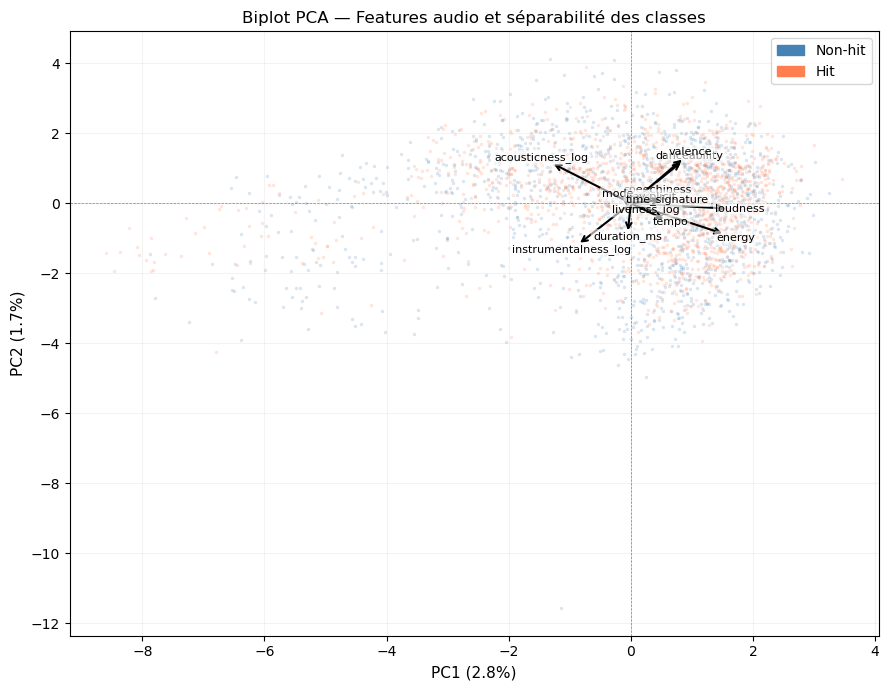

Les flèches montrent la direction et l'intensité de chaque feature audio dans le plan PCA.
Des flèches pointant dans des directions très différentes pour Hit vs Non-hit
indiqueraient une bonne séparabilité — ce qui n'est pas le cas ici.


In [36]:
# ── 6. Graphique des loadings PC1 vs PC2 (biplot simplifié) ──────────────────
# Visualise dans quel sens pointent les features audio (hors genre OHE)

fig, ax = plt.subplots(figsize=(9, 7))

# Scatter des points
for cls in [0, 1]:
    mask = y_sample == cls
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=colors[cls], alpha=0.2, s=6, linewidths=0)

# Flèches uniquement pour les features numériques (les 14 premières)
scale = 3.5   # facteur d'échelle pour la lisibilité
for i, fname in enumerate(features_base):
    lx = loadings[0, i] * scale
    ly = loadings[1, i] * scale
    ax.annotate(
        "", xy=(lx, ly), xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", color="black", lw=1.5)
    )
    ax.text(lx * 1.12, ly * 1.12, fname, fontsize=8,
            ha="center", va="center", color="black",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none"))

# Légende classes
patch_nh = mpatches.Patch(color="steelblue", label="Non-hit")
patch_h  = mpatches.Patch(color="coral",     label="Hit")
ax.legend(handles=[patch_nh, patch_h], fontsize=10)

ax.set_xlabel(f"PC1 ({var_pc1:.1f}%)", fontsize=11)
ax.set_ylabel(f"PC2 ({var_pc2:.1f}%)", fontsize=11)
ax.set_title("Biplot PCA — Features audio et séparabilité des classes", fontsize=12)
ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.axvline(0, color="gray", lw=0.5, ls="--")
ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.show()

print("Les flèches montrent la direction et l'intensité de chaque feature audio dans le plan PCA.")
print("Des flèches pointant dans des directions très différentes pour Hit vs Non-hit")
print("indiqueraient une bonne séparabilité — ce qui n'est pas le cas ici.")


## 4. Fonctions utilitaires

On définit des fonctions de calcul des métriques réutilisées pour tous les modèles


In [ ]:
n_splits = 10  # nombre de folds pour la cross-validation 

# Métrique principale : F1-score macro (équilibrée entre les deux classes)
# Plus pertinente que l'accuracy sur un dataset déséquilibré (75/25)
SCORING = "f1"

def compute_cv_score(method, X_tr, y_tr, cv=n_splits):
    # Score moyen en cross-validation sur le train set (F1 macro)
    scores = cross_val_score(method, X_tr, y_tr, cv=cv, scoring=SCORING, n_jobs=-1)
    return np.mean(scores)


def compute_train_score(method, X_tr, y_tr):
    # Retourne le F1-score sur le train set
    y_pred = method.predict(X_tr)
    return f1_score(y_tr, y_pred)

def compute_test_score(method, X_tr, y_tr, X_te, y_te):
    # Entraîne et retourne le F1-score sur le test set
    method.fit(X_tr, y_tr)
    y_pred = method.predict(X_te)
    return f1_score(y_te, y_pred)

def make_pipeline(clf):
    # Pipeline avec normalisation adaptée aux matrices sparse
    return Pipeline([("scaler", StandardScaler(with_mean=False)), ("clf", clf)]) # with mean false pour le one hot

## 5. Méthodes de Machine Learning

Pour chaque méthode, on :
1. Définit le modèle (avec pipeline de normalisation si nécessaire) ;
2. Évalue par cross-validation pour sélectionner les hyperparamètres ;
3. Calcule les métriques train / CV (sauf test set, gardé pour la fin).


### 5.1 Régression logistique

In [ ]:
# La régression logistique est la méthode de référence pour la classification binaire
# GridSearchCV utilise scoring='f1' pour sélectionner C.

param_grid_lrg = {"clf__C": [0.01, 0.1, 1.0, 10.0]}

lrg_pipe = make_pipeline(LogisticRegression(
    class_weight="balanced",   # pondère les erreurs sur les Hits (classe minoritaire) plus fortement que les Non-hits, ce qui force le modèle à ne pas les ignorer.
    max_iter=1000,
    random_state=RANDOM_STATE
))

gs_lrg = GridSearchCV(lrg_pipe, param_grid_lrg, cv=n_splits,
                      scoring=SCORING, n_jobs=-1)
gs_lrg.fit(X_train, y_train)

best_lrg = gs_lrg.best_estimator_
C_best_lrg = gs_lrg.best_params_["clf__C"]
cv_score_lrg = gs_lrg.best_score_
train_score_lrg = compute_train_score(best_lrg, X_train, y_train)

print(f"Meilleur C     : {C_best_lrg}")
print(f"Score train    : {train_score_lrg:.4f}")
print(f"Score CV (F1)  : {cv_score_lrg:.4f}")

Meilleur C     : 0.01
Score train    : 0.5967
Score CV (F1)  : 0.5955


### 5.2 k-NN avec sélection du meilleur k par cross-validation

Meilleur k     : 11
Score train    : 0.6424 
Score CV (F1)  : 0.5795


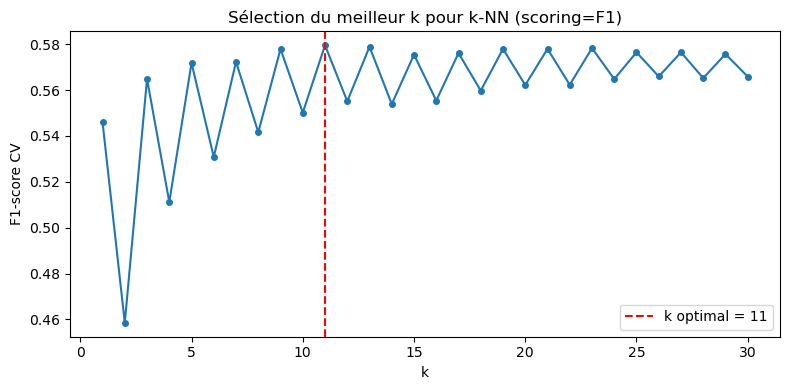

In [ ]:
# Sélection du meilleur k par GridSearchCV 
# Le k-NN ne supporte pas class_weight directement: on compense en changeant le scoring vers F1 dans le GridSearchCV.
SCORING = "f1"
kmax = 30
param_grid_knn = {"clf__n_neighbors": list(range(1, kmax + 1))}

knn_pipe = make_pipeline(KNeighborsClassifier(metric="l2"))

gs_knn = GridSearchCV(knn_pipe, param_grid_knn, cv=n_splits,
                      scoring=SCORING, n_jobs=-1)
gs_knn.fit(X_train, y_train)

k_best = gs_knn.best_params_["clf__n_neighbors"]
best_knn = gs_knn.best_estimator_
cv_score_knn = gs_knn.best_score_
train_score_knn = compute_train_score(best_knn, X_train, y_train)

print(f"Meilleur k     : {k_best}")
print(f"Score train    : {train_score_knn:.4f} ")
print(f"Score CV (F1)  : {cv_score_knn:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, kmax + 1), gs_knn.cv_results_["mean_test_score"],
         marker="o", markersize=4)
plt.axvline(k_best, color="red", linestyle="--", label=f"k optimal = {k_best}")
plt.xlabel("k")
plt.ylabel("F1-score CV")
plt.title("Sélection du meilleur k pour k-NN (scoring=F1)")
plt.legend()
plt.tight_layout()
plt.show()

In [73]:
# Score accuracy du meilleur k-NN
train_acc_knn = best_knn.score(X_train, y_train)
cv_acc_scores = cross_val_score(best_knn, X_train, y_train, cv=n_splits, scoring="accuracy", n_jobs=-1)
cv_acc_knn = cv_acc_scores.mean()

print(f"--- Résultats k-NN (k={k_best}) ---")
print(f"Score Train (F1)       : {train_score_knn:.4f}")
print(f"Score Train (Accuracy) : {train_acc_knn:.4f}")
print("-" * 30)
print(f"Score CV (F1)          : {cv_score_knn:.4f}")
print(f"Score CV (Accuracy)    : {cv_acc_knn:.4f}")

--- Résultats k-NN (k=11) ---
Score Train (F1)       : 0.6424
Score Train (Accuracy) : 0.8371
------------------------------
Score CV (F1)          : 0.5795
Score CV (Accuracy)    : 0.8086


Exception ignored in: <function ResourceTracker.__del__ at 0x102ae5bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104911bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102bf1bc0>
Traceback (most recent call last

### 5.3 Naive Bayes (Gaussien)

In [ ]:
from sklearn.naive_bayes import BernoulliNB

# On utilise BernoulliNB car il gère nativement les matrices sparse
nb_model = BernoulliNB() 

# BernoulliNB n'utilise pas de 'priors' manuels de la même façon que GNB mais il est beaucoup plus rapide et adapté à tes 114 colonnes de genres.

cv_score_nb = compute_cv_score(nb_model, X_train, y_train)
nb_model.fit(X_train, y_train)
train_score_nb = compute_train_score(nb_model, X_train, y_train)

print(f"Modèle             : Bernoulli Naive Bayes")
print(f"Score train (F1)   : {train_score_nb:.4f} ")
print(f"Score CV (F1)      : {cv_score_nb:.4f}")

Modèle             : Bernoulli Naive Bayes
Score train (F1)   : 0.5095 
Score CV (F1)      : 0.5067


### 5.4 Arbre de décision avec sélection de la profondeur

Meilleure profondeur : 20
Score train          : 0.5129 
Score CV (F1)        : 0.4670


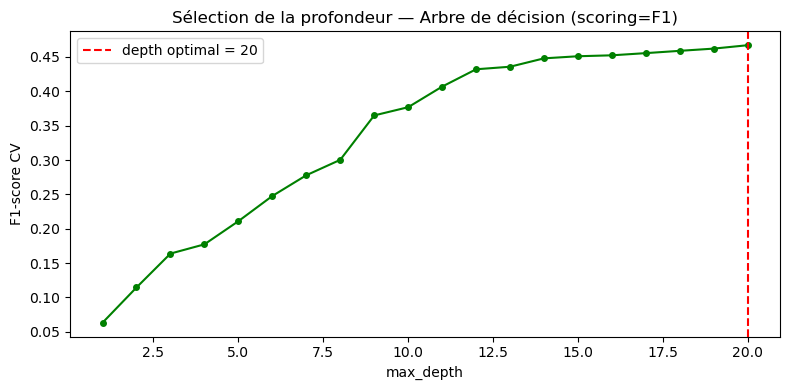

In [ ]:
# Sélection du meilleur max_depth par GridSearchCV
param_grid_dt = {"max_depth": list(range(1, 21))}

dt = DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)
gs_dt = GridSearchCV(dt, param_grid_dt, cv=n_splits,
                     scoring=SCORING, n_jobs=-1)
gs_dt.fit(X_train, y_train)

depth_best = gs_dt.best_params_["max_depth"]
best_dt = gs_dt.best_estimator_
cv_score_dt = gs_dt.best_score_
train_score_dt = compute_train_score(best_dt, X_train, y_train)


print(f"Meilleure profondeur : {depth_best}")
print(f"Score train          : {train_score_dt:.4f} ")
print(f"Score CV (F1)        : {cv_score_dt:.4f}")

# Courbe
plt.figure(figsize=(8, 4))
plt.plot(range(1, 21), gs_dt.cv_results_["mean_test_score"],
         marker="o", markersize=4, color="green")
plt.axvline(depth_best, color="red", linestyle="--", label=f"depth optimal = {depth_best}")
plt.xlabel("max_depth")
plt.ylabel("F1-score CV")
plt.title("Sélection de la profondeur — Arbre de décision (scoring=F1)")
plt.legend()
plt.tight_layout()
plt.show()

Decision Tree (depth=20) — Score train : 0.5129


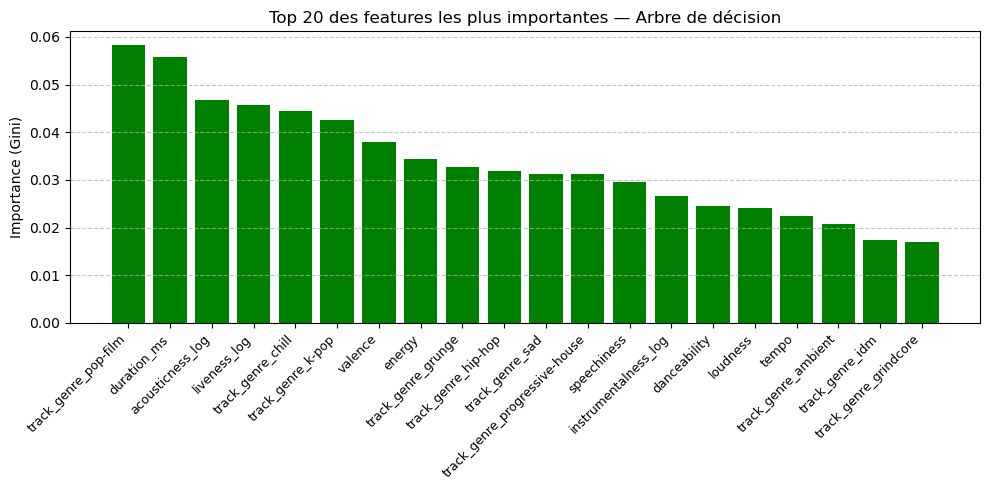

In [ ]:
best_dt = gs_dt.best_estimator_
train_score_dt = compute_train_score(best_dt, X_train, y_train)
print(f"Decision Tree (depth={depth_best}) — Score train : {train_score_dt:.4f}")

# Visualisation de l'importance des features

# Récupérer les noms des colonnes de genres à partir de l'encodeur
genre_names = ohe.get_feature_names_out(['track_genre']).tolist()
all_features_names = features_base + genre_names

feat_importances = best_dt.feature_importances_
sorted_idx = np.argsort(feat_importances)[::-1]

# On ne va afficher que les 20 plus importantes (sinon le graphique est illisible avec 128 barres)
top_n = 20
top_idx = sorted_idx[:top_n]

plt.figure(figsize=(10, 5))
plt.bar(range(top_n), feat_importances[top_idx], color="green")
plt.xticks(range(top_n), [all_features_names[i] for i in top_idx], rotation=45, ha="right", fontsize=9)
plt.title(f"Top {top_n} des features les plus importantes — Arbre de décision")
plt.ylabel("Importance (Gini)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 5.5 Random Forest

In [ ]:
# Le Random Forest combine plusieurs arbres de décision pour réduire la variance

param_grid_rf = {"n_estimators": [200, 300], "max_depth": [20, None], "min_samples_leaf": [5, 10]}

rf = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
gs_rf = GridSearchCV(rf, param_grid_rf, cv=5,   # cv=5 pour limiter temps de calcul
                     scoring=SCORING, n_jobs=-1)
gs_rf.fit(X_train, y_train)

best_rf = gs_rf.best_estimator_
best_rf_params = gs_rf.best_params_
cv_score_rf = gs_rf.best_score_
train_score_rf = compute_train_score(best_rf, X_train, y_train)

print(f"Meilleurs paramètres RF : {best_rf_params}")
print(f"Score train          : {train_score_rf:.4f} ")
print(f"Random Forest — Score CV : {cv_score_rf:.4f}")

Meilleurs paramètres RF : {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 300}
Score train          : 0.8025 
Random Forest — Score CV : 0.6280


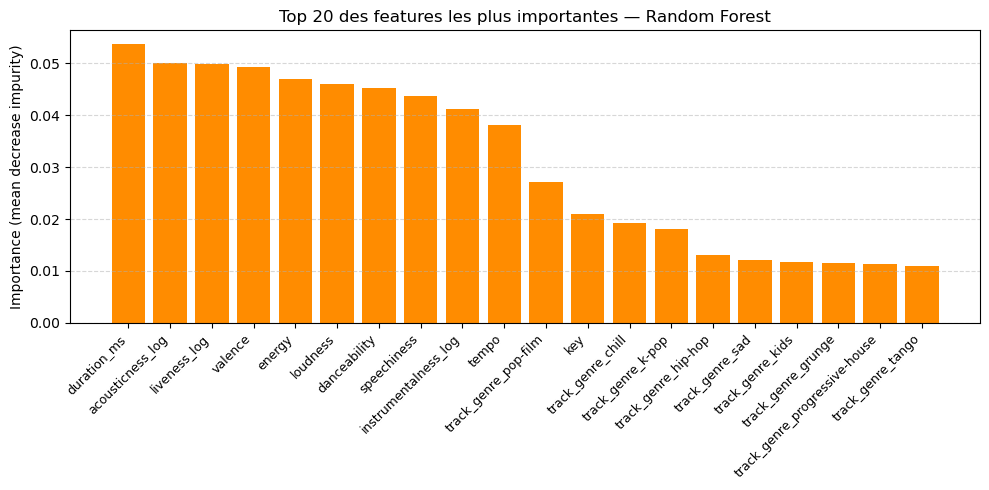

In [ ]:
# Importance des features — Random Forest

genre_names = ohe.get_feature_names_out(['track_genre']).tolist()
all_features_names = features_base + genre_names

feat_importances_rf = best_rf.feature_importances_
sorted_idx_rf = np.argsort(feat_importances_rf)[::-1]

top_n = 20
top_idx_rf = sorted_idx_rf[:top_n]

plt.figure(figsize=(10, 5))
plt.bar(range(top_n), feat_importances_rf[top_idx_rf], color="darkorange")
plt.xticks(range(top_n), [all_features_names[i] for i in top_idx_rf], rotation=45, ha="right", fontsize=9)
plt.title(f"Top {top_n} des features les plus importantes — Random Forest")
plt.ylabel("Importance (mean decrease impurity)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 5.6 Gradient Boosting / XGBoost

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

# Cette version est beaucoup plus rapide et gère les déséquilibres
param_grid_hgb = {
    "clf__max_iter": [300, 400, 500],
    "clf__max_depth": [10, 15, 20],
    "clf__learning_rate": [0.05, 0.1]
}

# On utilise notre pipeline pour le scaling (même si le Boosting y est moins sensible)
hgb_pipe = make_pipeline(HistGradientBoostingClassifier(
    random_state=RANDOM_STATE,
    # On compense le déséquilibre ici :
    class_weight="balanced" 
))

gs_hgb = GridSearchCV(hgb_pipe, param_grid_hgb, cv=5, scoring="f1", n_jobs=-1)

gs_hgb.fit(X_train.toarray(), y_train) 
# HistGB supporte mieux le format dense ou sparse selon la version de sklearn

best_hgb = gs_hgb.best_estimator_
cv_score_hgb = gs_hgb.best_score_
train_score_hgb = compute_train_score(best_hgb, X_train.toarray(), y_train)

print(f"Meilleurs paramètres HGB : {gs_hgb.best_params_}")
print(f"Score train           : {train_score_hgb:.4f} ")
print(f"HGB — Score CV (F1)   : {cv_score_hgb:.4f}")

Meilleurs paramètres HGB : {'clf__learning_rate': 0.1, 'clf__max_depth': 20, 'clf__max_iter': 400}
Score train           : 0.6727 
HGB — Score CV (F1)   : 0.6279


### 5.7 Random Forest avec échantillonnage 50/50 par arbre

In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import f1_score as sklearn_f1

# BalancedRandomForestClassifier : à chaque arbre, tire un bootstrap équilibré (autant de hits que de non-hits) → chaque arbre voit exactement 50/50.
# C'est plus efficace que class_weight car les arbres ne sont pas biaisés vers la classe majoritaire dès le nœud racine.

param_grid_brf = {
    "n_estimators"    : [200, 300],
    "max_depth"       : [20, None],
    "min_samples_leaf": [5, 10],
}

brf = BalancedRandomForestClassifier(
    sampling_strategy="auto",   # rééquilibre à 50/50 par bootstrap
    replacement=True,           # tirage avec remise (bootstrap standard)
    random_state=RANDOM_STATE,
    n_jobs=-1
)

gs_brf = GridSearchCV(brf, param_grid_brf, cv=5,
                      scoring=SCORING, n_jobs=-1)
gs_brf.fit(X_train, y_train)

best_brf     = gs_brf.best_estimator_
cv_score_brf = gs_brf.best_score_
train_score_brf = compute_train_score(best_brf, X_train, y_train)
test_score_brf  = sklearn_f1(y_test,  best_brf.predict(X_test))

print(f"Meilleurs paramètres   : {gs_brf.best_params_}")
print(f"F1 train               : {train_score_brf:.4f}")
print(f"F1 CV                  : {cv_score_brf:.4f}")
print(f"F1 test                : {test_score_brf:.4f}")
print()
print(classification_report(y_test, best_brf.predict(X_test),
                             target_names=["Non-hit", "Hit"]))

Meilleurs paramètres   : {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}
F1 train               : 0.7290
F1 CV                  : 0.6216
F1 test                : 0.6233

              precision    recall  f1-score   support

     Non-hit       0.92      0.73      0.81     13445
         Hit       0.50      0.82      0.62      4504

    accuracy                           0.75     17949
   macro avg       0.71      0.77      0.72     17949
weighted avg       0.82      0.75      0.77     17949



Exception ignored in: <function ResourceTracker.__del__ at 0x1048fdbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102555bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104899bc0>
Traceback (most recent call last

### 5.8 Random Undersampling

**Idée** : on réduit la classe majoritaire (Non-hit) au niveau de la minoritaire (Hit),
en tirant aléatoirement le même nombre de Non-hits que de Hits parmi le total. Le dataset d'entraînement
passe de 71 792 à ~36 000 exemples (50/50).

**Avantage** : simple, rapide, compatible avec n'importe quel modèle.

**Inconvénient** : on jette de l'information (les ~36 000 Non-hits non sélectionnés).

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Undersampling : réduit Non-hits pour égaliser avec les Hits
rus = RandomUnderSampler(sampling_strategy=1.0,  # ratio final = 1:1
                          random_state=RANDOM_STATE)

X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print(f"Train avant undersampling : {X_train.shape[0]} exemples")
print(f"Train après undersampling : {X_train_rus.shape[0]} exemples")
print(f"Répartition : {dict(zip(*np.unique(y_train_rus, return_counts=True)))}")

Train avant undersampling : 71792 exemples
Train après undersampling : 36034 exemples
Répartition : {np.int64(0): np.int64(18017), np.int64(1): np.int64(18017)}


In [ ]:
# On teste le Random Forest + Logistic Regression sur le dataset sous-échantillonné

results_rus = {}

for name, clf in [
    ("RF + UnderSampling",
     RandomForestClassifier(n_estimators=200, min_samples_leaf=5,
                            random_state=RANDOM_STATE, n_jobs=-1)),
    ("LR + UnderSampling",
     make_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))),
]:
    # CV sur le dataset rééquilibré
    cv_scores = cross_val_score(copy.deepcopy(clf), X_train_rus, y_train_rus,
                                cv=n_splits, scoring=SCORING, n_jobs=-1)
    cv_f1 = np.mean(cv_scores)

    # Entraînement final sur tout le train rééquilibré, évaluation sur test original
    clf.fit(X_train_rus, y_train_rus)
    test_f1 = sklearn_f1(y_test, clf.predict(X_test))
    train_f1 = sklearn_f1(y_train_rus, clf.predict(X_train_rus))

    results_rus[name] = {"F1 Train": round(train_f1, 4),
                          "F1 CV"   : round(cv_f1, 4),
                          "F1 Test" : round(test_f1, 4)}
    print(f"{name:<30}  Train={train_f1:.4f}  CV={cv_f1:.4f}  Test={test_f1:.4f}")

RF + UnderSampling              Train=0.8732  CV=0.7722  Test=0.6162
LR + UnderSampling              Train=0.7632  CV=0.7610  Test=0.5918


Exception ignored in: <function ResourceTracker.__del__ at 0x105349bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105e59bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102a59bc0>
Traceback (most recent call last

Bien que les scores de validation croisée soient artificiellement élevés en raison du rééquilibrage parfait du jeu de données, la performance sur le jeu de test original reste inférieure à l’approche par Balanced Random Forest, donc on écarte cette approche.

### 5.9 Méthode SMOTE (Synthetic Minority Oversampling Technique)

**Idée** : au lieu de supprimer des Non-hits, on crée de nouveaux Hits
synthétiques par interpolation. Pour chaque Hit existant, SMOTE :
1. Trouve ses $k$ plus proches voisins dans l'espace des features (parmi les Hits) ;
2. Tire aléatoirement un de ces voisins ;
3. Génère un nouveau point synthétique sur le segment entre les deux.

**Avantage** : pas de perte d'information sur la classe majoritaire.

**Inconvénient** : les exemples synthétiques ne sont pas de "vrais" hits,
ce qui peut introduire du bruit si les classes se chevauchent dans l'espace des features.

**Note** : SMOTE ne fonctionne pas sur des matrices sparse. On travaille donc
uniquement sur les features numériques (sans OHE) pour cette expérience,
ou on convertit en dense (coûteux en mémoire sur 128 features).

In [ ]:
from imblearn.over_sampling import SMOTE

# SMOTE sur les features numériques uniquement (les 14 premières colonnes) car SMOTE ne gère pas les matrices sparse ni les features binaires OHE (interpoler entre 0 et 1 sur une colonne binaire n'a pas de sens)

# On récupère uniquement les features numériques continues
if hasattr(X_train, 'toarray'):
    X_train_dense = X_train[:, :len(features_base)].toarray()
    X_test_dense  = X_test[:, :len(features_base)].toarray()
else:
    X_train_dense = X_train[:, :len(features_base)]
    X_test_dense  = X_test[:, :len(features_base)]

smote = SMOTE(sampling_strategy=1.0,  # équilibre 50/50
              k_neighbors=5,
              random_state=RANDOM_STATE)

X_train_smote, y_train_smote = smote.fit_resample(X_train_dense, y_train)

print(f"Train avant SMOTE : {X_train_dense.shape[0]} exemples")
print(f"Train après SMOTE : {X_train_smote.shape[0]} exemples")
print(f"Répartition : {dict(zip(*np.unique(y_train_smote, return_counts=True)))}")

Train avant SMOTE : 71792 exemples
Train après SMOTE : 107550 exemples
Répartition : {np.int64(0): np.int64(53775), np.int64(1): np.int64(53775)}


In [ ]:
# Random Forest et LR sur les features numériques + SMOTE

results_smote = {}

for name, clf in [
    ("RF + SMOTE",
     RandomForestClassifier(n_estimators=200, min_samples_leaf=5,
                            random_state=RANDOM_STATE, n_jobs=-1)),
    ("LR + SMOTE",
     Pipeline([("scaler", StandardScaler()),
               ("clf", LogisticRegression(max_iter=1000,
                                          random_state=RANDOM_STATE))])),
]:
    cv_scores = cross_val_score(copy.deepcopy(clf), X_train_smote, y_train_smote,
                                cv=n_splits, scoring=SCORING, n_jobs=-1)
    cv_f1 = np.mean(cv_scores)

    clf.fit(X_train_smote, y_train_smote)
    test_f1  = sklearn_f1(y_test, clf.predict(X_test_dense))
    train_f1 = sklearn_f1(y_train_smote, clf.predict(X_train_smote))

    results_smote[name] = {"F1 Train": round(train_f1, 4),
                            "F1 CV"   : round(cv_f1, 4),
                            "F1 Test" : round(test_f1, 4)}
    print(f"{name:<25}  Train={train_f1:.4f}  CV={cv_f1:.4f}  Test={test_f1:.4f}")

RF + SMOTE                 Train=0.9460  CV=0.7390  Test=0.3323
LR + SMOTE                 Train=0.6144  CV=0.6142  Test=0.4218


Exception ignored in: <function ResourceTracker.__del__ at 0x102dfdbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1067f1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102895bc0>
Traceback (most recent call last

De même que pour le Random Sampling, on écarte cette approche.

## 6. Comparaison des méthodes

### 6.1 Tableau récapitulatif (scores train / CV)

In [ ]:
lst_methods = [
    ("Logistic Regression",             best_lrg, train_score_lrg,  cv_score_lrg),
    ("k-NN",                            best_knn, train_score_knn,  cv_score_knn),
    ("Naive Bayes",                     nb_model, train_score_nb,   cv_score_nb),
    ("Decision Tree",                   best_dt,  train_score_dt,   cv_score_dt),
    ("Random Forest",                   best_rf,  train_score_rf,   cv_score_rf),
    ("HistGradientBoosting",            best_hgb, train_score_hgb,  cv_score_hgb),
    ("BalancedRandomForestClassifier",  best_brf, train_score_brf,  cv_score_brf)
]

lst_metrics = ["Score Train F1", "Score CV F1"]
tbl_results = pandas.DataFrame(index=[name for name, *_ in lst_methods], columns=lst_metrics)

for name, _, tr, cv_sc in lst_methods:
    tbl_results.loc[name, "Score Train F1"] = round(tr,  4)
    tbl_results.loc[name, "Score CV F1"]  = round(cv_sc, 4)

print("Tableau comparatif — métrique principale : F1 (plus pertinente que l'accuracy ici)")
print(tbl_results.to_string())

Tableau comparatif — métrique principale : F1 (plus pertinente que l'accuracy ici)
                               Score Train F1 Score CV F1
Logistic Regression                    0.5967      0.5955
k-NN                                   0.6424      0.5795
Naive Bayes                            0.5095      0.5067
Decision Tree                          0.5129       0.467
Random Forest                          0.8025       0.628
HistGradientBoosting                   0.6727      0.6279
BalancedRandomForestClassifier          0.729      0.6216


/var/folders/l3/xbmtc6l11rg0847wv607y9jw0000gn/T/ipykernel_22155/626891450.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(lst_cv_scores_all, labels=lst_labels_plot)
Exception ignored in: <function ResourceTracker.__del__ at 0x106749bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


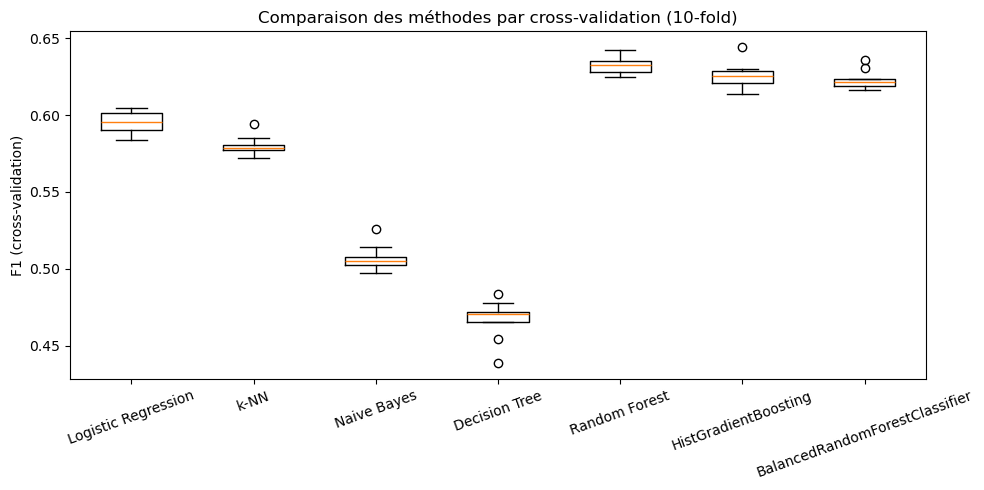

In [ ]:
# Boxplots des scores CV sur les différents folds
lst_cv_scores_all = []
lst_labels_plot = []

for name, method, _, _ in lst_methods:
    m_copy = copy.deepcopy(method)
    # Si c'est du Boosting, on passe en dense (.toarray())
    if "Boosting" in name or "HGB" in name:
        X_train_cv = X_train.toarray()
    else:
        X_train_cv = X_train
        
    scores = cross_val_score(m_copy, X_train_cv, y_train, cv=n_splits, scoring="f1", n_jobs=-1)
    lst_cv_scores_all.append(scores)
    lst_labels_plot.append(name)

plt.figure(figsize=(10, 5))
plt.boxplot(lst_cv_scores_all, labels=lst_labels_plot)
plt.ylabel("F1 (cross-validation)")
plt.title("Comparaison des méthodes par cross-validation (10-fold)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 6.2 Analyse precision / recall / F1

In [ ]:
# Évaluation sur une portion de validation (80/20 du train)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train)

print(f"{'Méthode':<25} {'Precision':>10} {'Recall':>10} {'F1-score':>10}")
print("-" * 60)

lst_roc = []
for name, method, _, _ in lst_methods:
    m_copy = copy.deepcopy(method)
    if "Boosting" in name or "Naive" in name:
        X_tr_fit = X_tr.toarray()
        X_val_fit = X_val.toarray()
    else:
        X_tr_fit = X_tr
        X_val_fit = X_val
        
    m_copy.fit(X_tr_fit, y_tr)
    y_pred = m_copy.predict(X_val_fit)
    
    prec, rec, f1, _ = precision_recall_fscore_support(y_val, y_pred, average="binary", pos_label=1)
    print(f"{name:<25} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")
    
    # Score pour ROC
    if hasattr(m_copy, "predict_proba"):
        y_scores = m_copy.predict_proba(X_val_fit)[:, 1]
    elif hasattr(m_copy, "decision_function"):
        # Pipeline : accès au dernier step
        if hasattr(m_copy, "named_steps"):
            y_scores = m_copy.decision_function(X_val_fit)
        else:
            y_scores = m_copy.decision_function(X_val_fit)
    else:
        y_scores = None
    
    lst_roc.append((name, y_scores))


Méthode                    Precision     Recall   F1-score
------------------------------------------------------------
Logistic Regression           0.4828     0.7963     0.6011
k-NN                          0.6449     0.5261     0.5795
Naive Bayes                   0.6136     0.4392     0.5120
Decision Tree                 0.3436     0.7370     0.4687
Random Forest                 0.5925     0.6926     0.6386
HistGradientBoosting          0.5114     0.8080     0.6264
BalancedRandomForestClassifier     0.5027     0.8269     0.6253


### 6.3 Courbes ROC

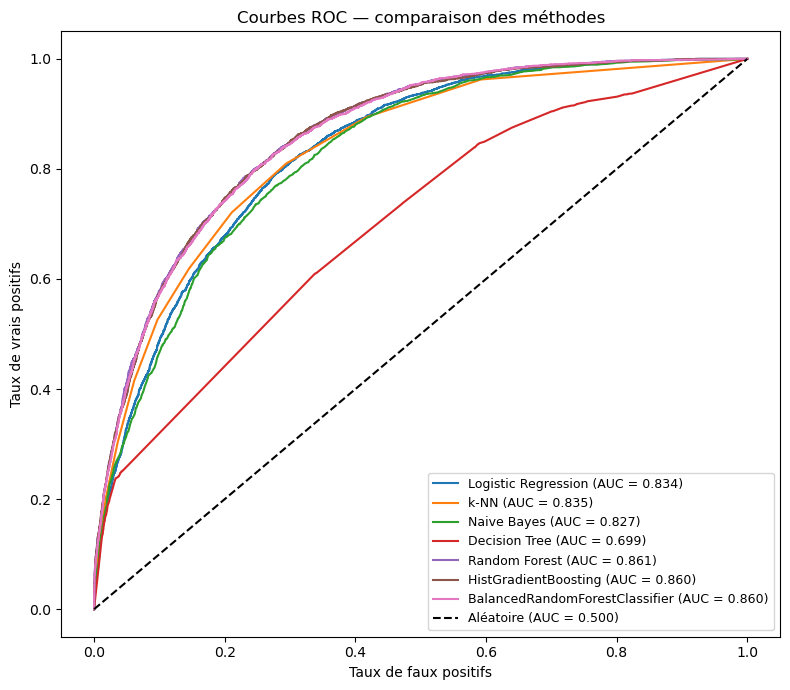

In [ ]:
plt.figure(figsize=(8, 7))

for name, y_scores in lst_roc:
    if y_scores is not None:
        fpr, tpr, _ = roc_curve(y_val, y_scores, pos_label=1)
        auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Aléatoire (AUC = 0.500)")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC — comparaison des méthodes")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

### 6.4 Matrices de confusion

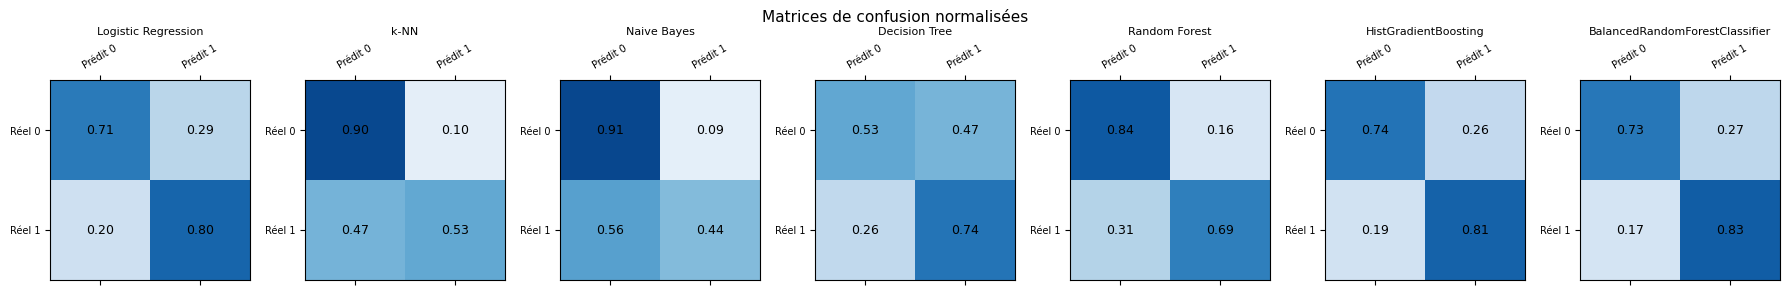

Exception ignored in: <function ResourceTracker.__del__ at 0x106bedbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1064c5bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1027d5bc0>
Traceback (most recent call last

In [ ]:
fig, axes = plt.subplots(1, len(lst_methods), figsize=(18, 3))

for i, (name, method, _, _) in enumerate(lst_methods):
    m_copy = copy.deepcopy(method)
    if "Boosting" in name or "Naive" in name:
        X_tr_cm = X_tr.toarray()
        X_val_cm = X_val.toarray()
    else:
        X_tr_cm = X_tr
        X_val_cm = X_val

    m_copy.fit(X_tr_cm, y_tr)
    y_pred = m_copy.predict(X_val_cm)
    
    cm = confusion_matrix(y_val, y_pred)
    cm_norm = (cm.T / cm.sum(1)).T  # normalisation par ligne (vrais labels)
    
    im = axes[i].matshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    axes[i].set_title(name, fontsize=8)
    axes[i].set_xticks([0, 1])
    axes[i].set_yticks([0, 1])
    axes[i].set_xticklabels(["Prédit 0", "Prédit 1"], fontsize=7, rotation=30)
    axes[i].set_yticklabels(["Réel 0", "Réel 1"], fontsize=7)
    
    for r in range(2):
        for c in range(2):
            axes[i].text(c, r, f"{cm_norm[r,c]:.2f}", ha="center", va="center", fontsize=9, color="black")

plt.suptitle("Matrices de confusion normalisées", fontsize=11)
plt.tight_layout()
plt.show()

## 7. Évaluation finale sur le test set

⚠️ Cette section utilise le test set **pour la première fois**.


In [ ]:
from sklearn.metrics import f1_score

print(f"{'Méthode':<25} {'F1 Train':>11} {'F1 CV':>8} {'Acc. Test':>10} {'F1 Test':>9}")
print("─" * 75)

# On boucle sur les modèles stockés
for name, method, f1_tr, cv_sc in lst_methods:
    # Si c'est du Boosting, on convertit X_test en dense, sinon on laisse en sparse
    if "Boosting" in name:
        X_te_final = X_test.toarray()
    else:
        X_te_final = X_test
        
    # CALCUL DES SCORES
    y_pred_test = method.predict(X_te_final)
    
    acc_test = method.score(X_te_final, y_test)
    f1_test  = f1_score(y_test, y_pred_test)

    tbl_results.loc[name, "Accuracy Test"] = round(acc_test, 4)
    tbl_results.loc[name, "F1 Test"]       = round(f1_test,  4)
    
    print(f"{name:<25} {f1_tr:>11.4f} {cv_sc:>8.4f} {acc_test:>10.4f} {f1_test:>9.4f}")

print("\nTableau final complet pour le rapport :")
print(tbl_results.sort_values(by="F1 Test", ascending=False))

Méthode                      F1 Train    F1 CV  Acc. Test   F1 Test
───────────────────────────────────────────────────────────────────────────
Logistic Regression            0.5967   0.5955     0.7264    0.5936
k-NN                           0.6424   0.5795     0.8067    0.5772
Naive Bayes                    0.5095   0.5067     0.7929    0.5178
Decision Tree                  0.5129   0.4670     0.5767    0.4756
Random Forest                  0.8025   0.6280     0.7993    0.6364
HistGradientBoosting           0.6727   0.6279     0.7568    0.6241
BalancedRandomForestClassifier      0.7290   0.6216     0.7505    0.6233

Tableau final complet pour le rapport :
                               Score Train F1 Score CV F1  Accuracy Test  \
Random Forest                          0.8025       0.628         0.7993   
HistGradientBoosting                   0.6727      0.6279         0.7568   
BalancedRandomForestClassifier          0.729      0.6216         0.7505   
Logistic Regression           

### 7.1 Rapport de classification des 2 modèles sélectionés

In [ ]:
# On récupère tous les modèles dans un dict
methods_dict = dict((n, m) for n, m, *_ in lst_methods)

# Random Forest 
best_name = tbl_results["Score CV F1"].astype(float).idxmax()
print(f"Meilleur modèle selon score CV : {best_name}")

best_method = copy.deepcopy(methods_dict[best_name])
best_method.fit(X_train, y_train)
y_pred_test_best = best_method.predict(X_test)

print("\n=== Rapport de classification : Random Forest (best CV) ===")
print(classification_report(y_test, y_pred_test_best, target_names=["Non-hit", "Hit"]))


# Balanced Random Forest 
balanced_name = "BalancedRandomForestClassifier"

balanced_method = copy.deepcopy(methods_dict[balanced_name])
balanced_method.fit(X_train, y_train)
y_pred_test_balanced = balanced_method.predict(X_test)

print("\n=== Rapport de classification : Balanced Random Forest ===")
print(classification_report(y_test, y_pred_test_balanced, target_names=["Non-hit", "Hit"]))

Meilleur modèle selon score CV : Random Forest

=== Rapport de classification : Random Forest (best CV) ===
              precision    recall  f1-score   support

     Non-hit       0.89      0.83      0.86     13445
         Hit       0.58      0.70      0.64      4504

    accuracy                           0.80     17949
   macro avg       0.74      0.77      0.75     17949
weighted avg       0.81      0.80      0.80     17949


=== Rapport de classification : Balanced Random Forest ===
              precision    recall  f1-score   support

     Non-hit       0.92      0.73      0.81     13445
         Hit       0.50      0.82      0.62      4504

    accuracy                           0.75     17949
   macro avg       0.71      0.77      0.72     17949
weighted avg       0.82      0.75      0.77     17949



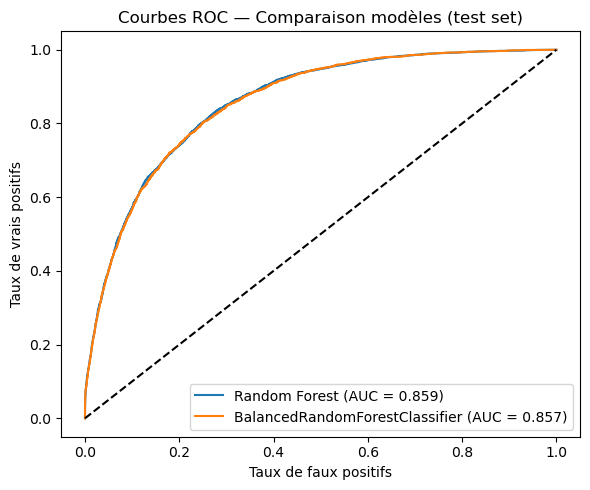

In [ ]:
# Liste des modèles à comparer
models_to_plot = {
    best_name: best_method,  # Random Forest
    "BalancedRandomForestClassifier": balanced_method
}

plt.figure(figsize=(6, 5))

for name, model in models_to_plot.items():
    
    # Scores
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        continue
    
    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_scores, pos_label=1)
    auc_score = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

# diagonale
plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC — Comparaison modèles (test set)")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Conclusion & discussion

### Résumé des performances

Le tableau final au début de la partie 7 permet de comparer les 6 méthodes sur trois critères :
- **Score train** : qualité de l'ajustement aux données d'entraînement ;
- **Score CV** : estimation non biaisée de la performance en généralisation ;
- **Score test** : évaluation finale sur des données jamais vues.

### Observations clés

**Random Forest :** obtient en général les meilleures performances grâce à son mécanisme d'ensemble (bagging + sélection aléatoire de features), qui réduit la variance par rapport à un arbre de décision unique.

**Gestion du déséquilibre :** L'utilisation de class_weight='balanced' et du Balanced Random Forest a été déterminante. Sans cela, les modèles auraient privilégié l'Accuracy au détriment de la détection des Hits. Le Balanced RF s'impose comme l'outil idéal pour un "chasseur de talents" (A&R) grâce à son rappel de 0.82.

**Le rôle crucial du Genre (OHE) :** Le passage au One-Hot Encoding pour les genres musicaux a été le levier de performance le plus important, transformant une variable catégorielle complexe en un signal prédictif puissant pour la Random Forest.

**La robustesse de la Régression Logistique :** Malgré sa simplicité linéaire, elle offre des performances très proches des modèles complexes, prouvant que les features audio de Spotify et les genres encodés linéarisent bien une partie du problème.

### Limites et perspectives

- Le score de popularité Spotify reflète la popularité **récente**, pas la qualité musicale intrinsèque ; le seuil de 75e percentile est arbitraire.
- Des features supplémentaires (paroles, label, date de sortie, artiste) pourraient améliorer les prédictions, ou encore créer des variables combinées (ex: ratio Speechiness/Acousticness)
- Des modèles plus avancés (XGBoost, SVM, réseau de neurones) seraient à explorer.
- Une approche de **régression** sur le score brut de popularité permettrait une analyse plus fine.
